# Rice Leaf Disease Classification using ResNet50 and PyTorch

Degree: MSc Data Analytics

Module: Computer Vision and Artificial Intelligence

Dataset: Rice Leaf Disease Dataset (Kaggle)

Framework: PyTorch

Model: ResNet50 with Transfer Learning

## Step 1: Install Required Libraries

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import ResNet50_Weights

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch version:', torch.__version__)
print('Device in use:', DEVICE)
if torch.cuda.is_available():
    print('GPU name:', torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
Device in use: cuda
GPU name: Tesla T4


## Step 2: Download Rice Leaf Disease Dataset from Kaggle

In [2]:
from google.colab import files

print('Upload your kaggle.json API key.')
print('Go to: kaggle.com -> Settings -> API -> Create New Token')
files.upload()

Upload your kaggle.json API key.
Go to: kaggle.com -> Settings -> API -> Create New Token


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"zubaidvjbk","key":"e2d6c3830a3e6b7fb9493893003440a6"}'}

In [3]:
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
os.system('cp kaggle.json ~/.kaggle/')
os.system('chmod 600 ~/.kaggle/kaggle.json')

os.system('kaggle datasets download -d minhhuy2810/rice-diseases-image-dataset --quiet')
os.system('unzip -q rice-diseases-image-dataset.zip -d rice_data')

print('Dataset downloaded and extracted.')
print('Source: https://www.kaggle.com/datasets/minhhuy2810/rice-diseases-image-dataset')

Dataset downloaded and extracted.
Source: https://www.kaggle.com/datasets/minhhuy2810/rice-diseases-image-dataset


## Step 3: Explore Dataset Structure

In [4]:
ROOT = 'rice_data'

for root, dirs, files_list in os.walk(ROOT):
    depth = root.replace(ROOT, '').count(os.sep)
    indent = '  ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    if depth == 2:
        print(f'{indent}  ({len(files_list)} images)')

rice_data/
  LabelledRice/
    Labelled/
      (0 images)
      LeafBlast/
      Healthy/
      BrownSpot/
      Hispa/
  RiceDiseaseDataset/
    validation/
      (0 images)
      LeafBlast/
      Healthy/
      BrownSpot/
      Hispa/
    train/
      (0 images)
      LeafBlast/
      Healthy/
      BrownSpot/
      Hispa/


In [5]:
DATA_DIR = None
for root, dirs, files_list in os.walk(ROOT):
    if len(dirs) >= 3 and all(
        any(f.lower().endswith(('.jpg', '.jpeg', '.png'))
            for f in os.listdir(os.path.join(root, d)))
        for d in dirs
    ):
        DATA_DIR = root
        break

print('Data directory found:', DATA_DIR)

class_names = sorted(os.listdir(DATA_DIR))
num_classes = len(class_names)

print('Number of classes:', num_classes)
print()

total_images = 0
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    count = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    class_counts[cls] = count
    total_images += count
    print(f'  {cls}: {count} images')

print()
print('Total images:', total_images)

Data directory found: rice_data/LabelledRice/Labelled
Number of classes: 4

  BrownSpot: 523 images
  Healthy: 1488 images
  Hispa: 565 images
  LeafBlast: 779 images

Total images: 3355


## Step 4: Visualise Sample Images per Class

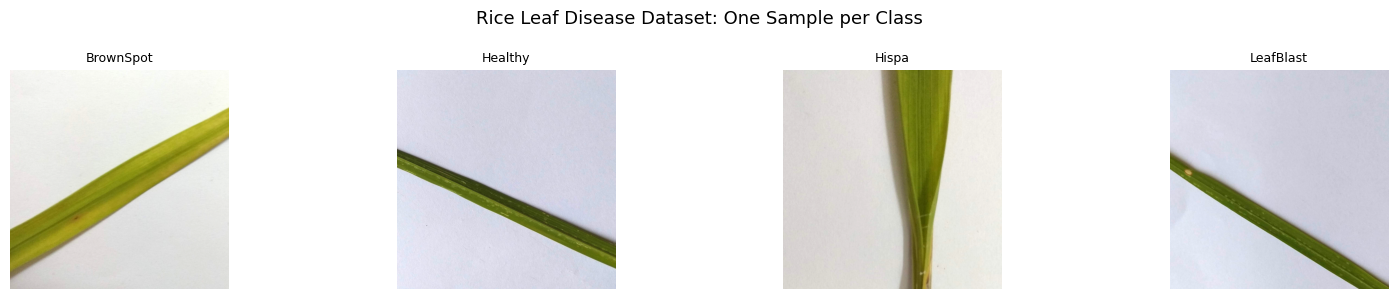

Sample image grid saved.


In [6]:
cols = min(num_classes, 4)
rows = (num_classes + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
if rows == 1:
    axes = [axes]
axes_flat = [ax for row in axes for ax in (row if hasattr(row, '__iter__') else [row])]

fig.suptitle('Rice Leaf Disease Dataset: One Sample per Class', fontsize=13)

for ax, cls in zip(axes_flat, class_names):
    cls_path = os.path.join(DATA_DIR, cls)
    img_files = [
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    chosen = random.choice(img_files)
    img = Image.open(os.path.join(cls_path, chosen)).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls.replace('_', ' '), fontsize=9)
    ax.axis('off')

for ax in axes_flat[num_classes:]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample image grid saved.')

## Step 5: Class Distribution Chart

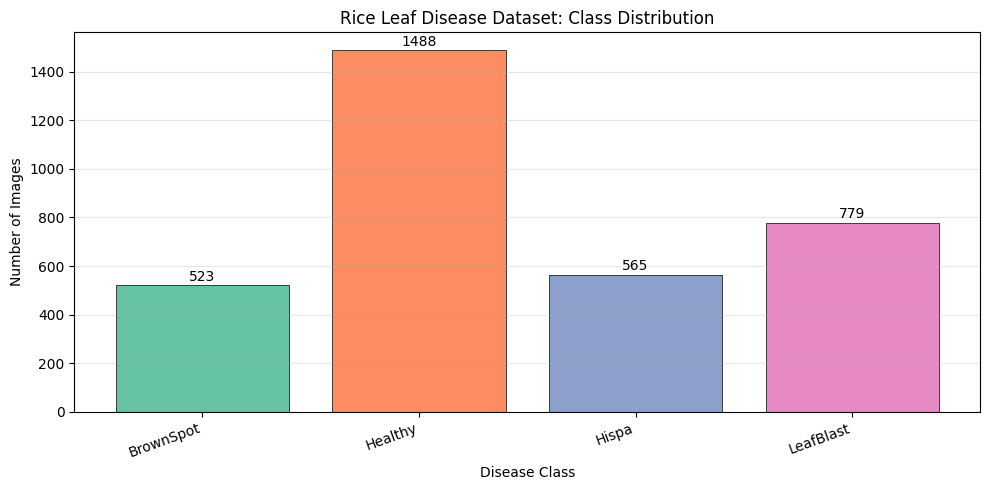

Class distribution chart saved.


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = plt.cm.Set2.colors[:num_classes]
bars = ax.bar(class_names, list(class_counts.values()), color=colors, edgecolor='black', linewidth=0.5)

for bar, count in zip(bars, class_counts.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(count),
        ha='center', va='bottom', fontsize=10
    )

ax.set_xlabel('Disease Class')
ax.set_ylabel('Number of Images')
ax.set_title('Rice Leaf Disease Dataset: Class Distribution')
ax.set_xticklabels([c.replace('_', ' ') for c in class_names], rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Class distribution chart saved.')

## Step 6: Define Transforms and Build Datasets

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32
TRAIN_RATIO = 0.75
VAL_RATIO = 0.15
TEST_RATIO = 0.10

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

full_dataset = datasets.ImageFolder(root=DATA_DIR)
total_size = len(full_dataset)

train_size = int(TRAIN_RATIO * total_size)
val_size   = int(VAL_RATIO * total_size)
test_size  = total_size - train_size - val_size

indices = list(range(total_size))
random.shuffle(indices)

train_indices = indices[:train_size]
val_indices   = indices[train_size:train_size + val_size]
test_indices  = indices[train_size + val_size:]

print('Dataset split (75 / 15 / 10):')
print('  Total images :', total_size)
print('  Train        :', train_size)
print('  Validation   :', val_size)
print('  Test         :', test_size)
print('  Classes      :', full_dataset.classes)
print('  Class to idx :', full_dataset.class_to_idx)

Dataset split (75 / 15 / 10):
  Total images : 3355
  Train        : 2516
  Validation   : 503
  Test         : 336
  Classes      : ['BrownSpot', 'Healthy', 'Hispa', 'LeafBlast']
  Class to idx : {'BrownSpot': 0, 'Healthy': 1, 'Hispa': 2, 'LeafBlast': 3}


In [9]:
from torch.utils.data import Subset

class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

base_dataset = datasets.ImageFolder(root=DATA_DIR)

train_subset = Subset(base_dataset, train_indices)
val_subset   = Subset(base_dataset, val_indices)
test_subset  = Subset(base_dataset, test_indices)

train_dataset = TransformDataset(train_subset, train_transform)
val_dataset   = TransformDataset(val_subset,   test_transform)
test_dataset  = TransformDataset(test_subset,  test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('DataLoaders created.')
print('  Train batches      :', len(train_loader))
print('  Validation batches :', len(val_loader))
print('  Test batches       :', len(test_loader))

batch_imgs, batch_labels = next(iter(train_loader))
print('  Batch image shape  :', batch_imgs.shape)
print('  Batch label shape  :', batch_labels.shape)

DataLoaders created.
  Train batches      : 79
  Validation batches : 16
  Test batches       : 11
  Batch image shape  : torch.Size([32, 3, 224, 224])
  Batch label shape  : torch.Size([32])


## Step 7: Build ResNet50 Model with Custom Head

In [10]:
def build_resnet50(num_classes, freeze_backbone=True):
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.fc.in_features

    model.fc = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(256, num_classes)
    )

    return model


model = build_resnet50(num_classes=num_classes, freeze_backbone=True)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params

print('ResNet50 Model Summary')
print('  Backbone              : ResNet50 (IMAGENET1K_V2 weights)')
print('  Input size            : 224 x 224 x 3')
print('  Output classes        : ', num_classes)
print('  Custom head           : Linear(2048->256) -> ReLU -> Dropout(0.5) -> Linear(256->num_classes)')
print('  Total parameters      : ', f'{total_params:,}')
print('  Trainable parameters  : ', f'{trainable_params:,}')
print('  Frozen parameters     : ', f'{frozen_params:,}')
print()
print('Custom classifier head:')
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


ResNet50 Model Summary
  Backbone              : ResNet50 (IMAGENET1K_V2 weights)
  Input size            : 224 x 224 x 3
  Output classes        :  4
  Custom head           : Linear(2048->256) -> ReLU -> Dropout(0.5) -> Linear(256->num_classes)
  Total parameters      :  24,033,604
  Trainable parameters  :  525,572
  Frozen parameters     :  23,508,032

Custom classifier head:
Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=4, bias=True)
)


## Step 8: Define Loss, Optimizer and Scheduler

In [11]:
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 8
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-4

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE1,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

print('Loss function : CrossEntropyLoss')
print('Optimizer     : Adam  (lr =', LR_PHASE1, ', weight_decay = 1e-4)')
print('Scheduler     : StepLR (step_size = 4, gamma = 0.5)')

Loss function : CrossEntropyLoss
Optimizer     : Adam  (lr = 0.001 , weight_decay = 1e-4)
Scheduler     : StepLR (step_size = 4, gamma = 0.5)


## Step 9: Training and Validation Functions

In [12]:
def run_epoch(model, loader, criterion, optimizer, is_train, device):
    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()

    with context:
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

    avg_loss = total_loss / total_samples
    avg_acc  = total_correct / total_samples
    return avg_loss, avg_acc


print('Training and validation functions defined.')

Training and validation functions defined.


## Step 10: Phase 1 Training (Backbone Frozen)

In [13]:
import copy

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : []
}

best_val_acc  = 0.0
best_weights  = None

print('Phase 1: Training classifier head only (backbone frozen)')
print(f'Epochs: {EPOCHS_PHASE1}   LR: {LR_PHASE1}')
print()
print(f'{"Epoch":<8} {"Train Loss":<14} {"Train Acc":<14} {"Val Loss":<14} {"Val Acc":<12}')
print('-' * 62)

for epoch in range(1, EPOCHS_PHASE1 + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, True, DEVICE)
    vl_loss, vl_acc = run_epoch(model, val_loader, criterion, optimizer, False, DEVICE)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

    print(f'{epoch:<8} {tr_loss:<14.4f} {tr_acc * 100:<14.2f} {vl_loss:<14.4f} {vl_acc * 100:<12.2f}')

print('-' * 62)
print(f'Phase 1 done. Best validation accuracy: {best_val_acc * 100:.2f}%')

Phase 1: Training classifier head only (backbone frozen)
Epochs: 10   LR: 0.001

Epoch    Train Loss     Train Acc      Val Loss       Val Acc     
--------------------------------------------------------------
1        1.2132         48.21          1.0467         58.85       
2        1.0995         54.37          1.0583         55.27       
3        1.0778         54.45          1.0543         55.07       
4        1.0226         57.47          0.9754         62.03       
5        0.9962         58.78          0.9579         62.62       
6        1.0008         59.18          0.9609         61.43       
7        0.9718         60.53          0.9837         58.85       
8        0.9863         59.54          0.9689         59.44       
9        0.9587         60.57          0.9492         60.64       
10       0.9394         61.69          0.9457         61.63       
--------------------------------------------------------------
Phase 1 done. Best validation accuracy: 62.62%


## Step 11: Phase 2 Fine-Tuning (Unfreeze layer3 and layer4)

In [14]:
for name, param in model.named_parameters():
    if 'layer3' in name or 'layer4' in name or 'fc' in name:
        param.requires_grad = True

trainable_p2 = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Phase 2 trainable parameters: {trainable_p2:,}')
print('Unfrozen: layer3, layer4, and fc')

optimizer_p2 = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_PHASE2,
    weight_decay=1e-4
)
scheduler_p2 = optim.lr_scheduler.StepLR(optimizer_p2, step_size=3, gamma=0.5)

print()
print('Phase 2: Fine-tuning layer3, layer4, and fc')
print(f'Epochs: {EPOCHS_PHASE2}   LR: {LR_PHASE2}')
print()
print(f'{"Epoch":<8} {"Train Loss":<14} {"Train Acc":<14} {"Val Loss":<14} {"Val Acc":<12}')
print('-' * 62)

for epoch in range(EPOCHS_PHASE1 + 1, EPOCHS_PHASE1 + EPOCHS_PHASE2 + 1):
    tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer_p2, True, DEVICE)
    vl_loss, vl_acc = run_epoch(model, val_loader, criterion, optimizer_p2, False, DEVICE)
    scheduler_p2.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = copy.deepcopy(model.state_dict())

    print(f'{epoch:<8} {tr_loss:<14.4f} {tr_acc * 100:<14.2f} {vl_loss:<14.4f} {vl_acc * 100:<12.2f}')

print('-' * 62)
print(f'Phase 2 done. Best validation accuracy: {best_val_acc * 100:.2f}%')

model.load_state_dict(best_weights)
print('Best model weights restored.')

Phase 2 trainable parameters: 22,588,676
Unfrozen: layer3, layer4, and fc

Phase 2: Fine-tuning layer3, layer4, and fc
Epochs: 8   LR: 0.0001

Epoch    Train Loss     Train Acc      Val Loss       Val Acc     
--------------------------------------------------------------
11       0.8517         66.30          0.7286         73.76       
12       0.7197         71.03          0.6472         77.34       
13       0.6578         74.01          0.5958         79.52       
14       0.5879         77.03          0.5574         81.11       
15       0.5585         77.94          0.5449         80.91       
16       0.5160         79.65          0.5607         79.72       
17       0.4884         81.04          0.5383         79.92       
18       0.4737         82.11          0.5294         80.72       
--------------------------------------------------------------
Phase 2 done. Best validation accuracy: 81.11%
Best model weights restored.


## Step 12: Plot Training History

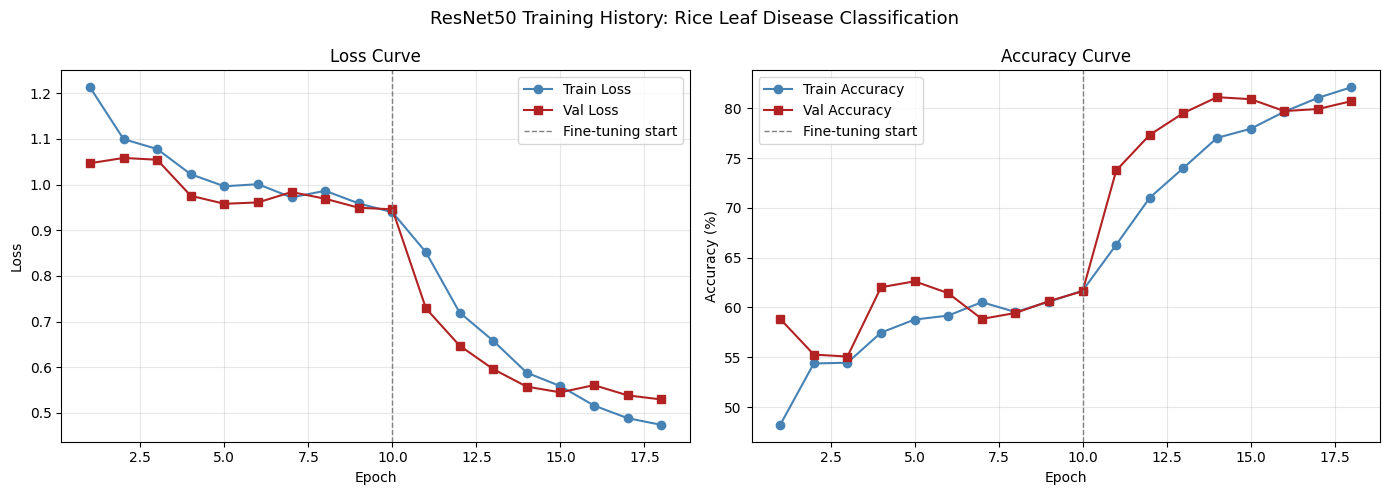

Training history saved.


In [15]:
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2
ep_range = list(range(1, total_epochs + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet50 Training History: Rice Leaf Disease Classification', fontsize=13)

axes[0].plot(ep_range, history['train_loss'], color='steelblue', marker='o', label='Train Loss')
axes[0].plot(ep_range, history['val_loss'],   color='firebrick', marker='s', label='Val Loss')
axes[0].axvline(x=EPOCHS_PHASE1, color='gray', linestyle='dashed', linewidth=1, label='Fine-tuning start')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(ep_range, [v * 100 for v in history['train_acc']], color='steelblue', marker='o', label='Train Accuracy')
axes[1].plot(ep_range, [v * 100 for v in history['val_acc']],   color='firebrick', marker='s', label='Val Accuracy')
axes[1].axvline(x=EPOCHS_PHASE1, color='gray', linestyle='dashed', linewidth=1, label='Fine-tuning start')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Accuracy Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training history saved.')

## Step 13: Evaluate on Test Set

In [16]:
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc  = accuracy_score(all_labels, all_preds)
test_prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_rec  = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
test_f1   = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print('Test Set Evaluation Results')
print('  Accuracy           :', round(test_acc  * 100, 2), '%')
print('  Weighted Precision :', round(test_prec * 100, 2), '%')
print('  Weighted Recall    :', round(test_rec  * 100, 2), '%')
print('  Weighted F1 Score  :', round(test_f1   * 100, 2), '%')
print()
print('Per-class Classification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

Test Set Evaluation Results
  Accuracy           : 74.7 %
  Weighted Precision : 75.5 %
  Weighted Recall    : 74.7 %
  Weighted F1 Score  : 74.16 %

Per-class Classification Report:
              precision    recall  f1-score   support

   BrownSpot       0.75      0.74      0.75        58
     Healthy       0.76      0.91      0.83       143
       Hispa       0.57      0.57      0.57        51
   LeafBlast       0.86      0.58      0.70        84

    accuracy                           0.75       336
   macro avg       0.74      0.70      0.71       336
weighted avg       0.75      0.75      0.74       336



## Step 14: Confusion Matrix

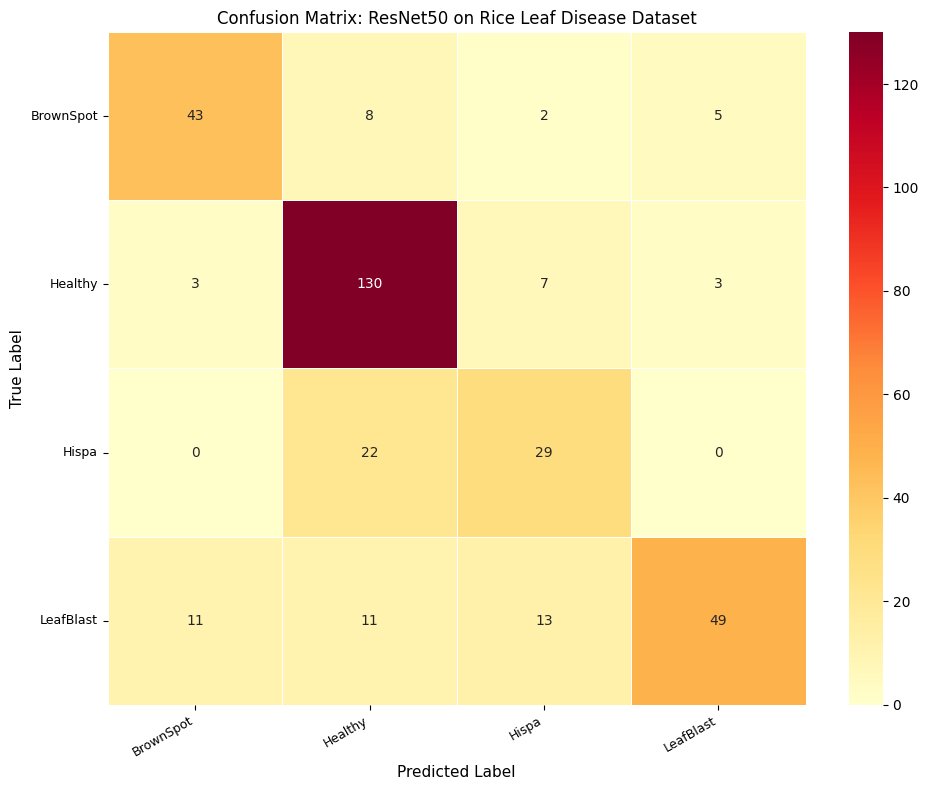

Confusion matrix saved.


In [17]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    xticklabels=[c.replace('_', ' ') for c in class_names],
    yticklabels=[c.replace('_', ' ') for c in class_names],
    linewidths=0.5,
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
ax.set_title('Confusion Matrix: ResNet50 on Rice Leaf Disease Dataset', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved.')

## Step 15: Per-Class Accuracy Bar Chart

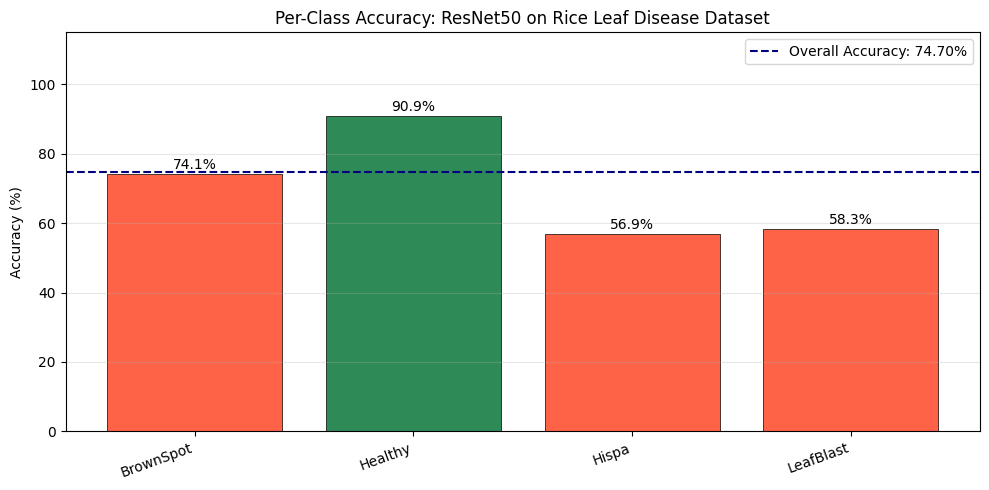

In [18]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

bar_colors = [
    'seagreen'   if a >= 0.90 else
    'goldenrod'  if a >= 0.75 else
    'tomato'
    for a in per_class_acc
]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [c.replace('_', ' ') for c in class_names],
    per_class_acc * 100,
    color=bar_colors,
    edgecolor='black',
    linewidth=0.5
)

for bar, val in zip(bars, per_class_acc):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val * 100:.1f}%',
        ha='center', va='bottom', fontsize=10
    )

ax.axhline(
    y=test_acc * 100,
    color='navy',
    linestyle='dashed',
    linewidth=1.5,
    label=f'Overall Accuracy: {test_acc * 100:.2f}%'
)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Per-Class Accuracy: ResNet50 on Rice Leaf Disease Dataset')
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 16: Sample Predictions

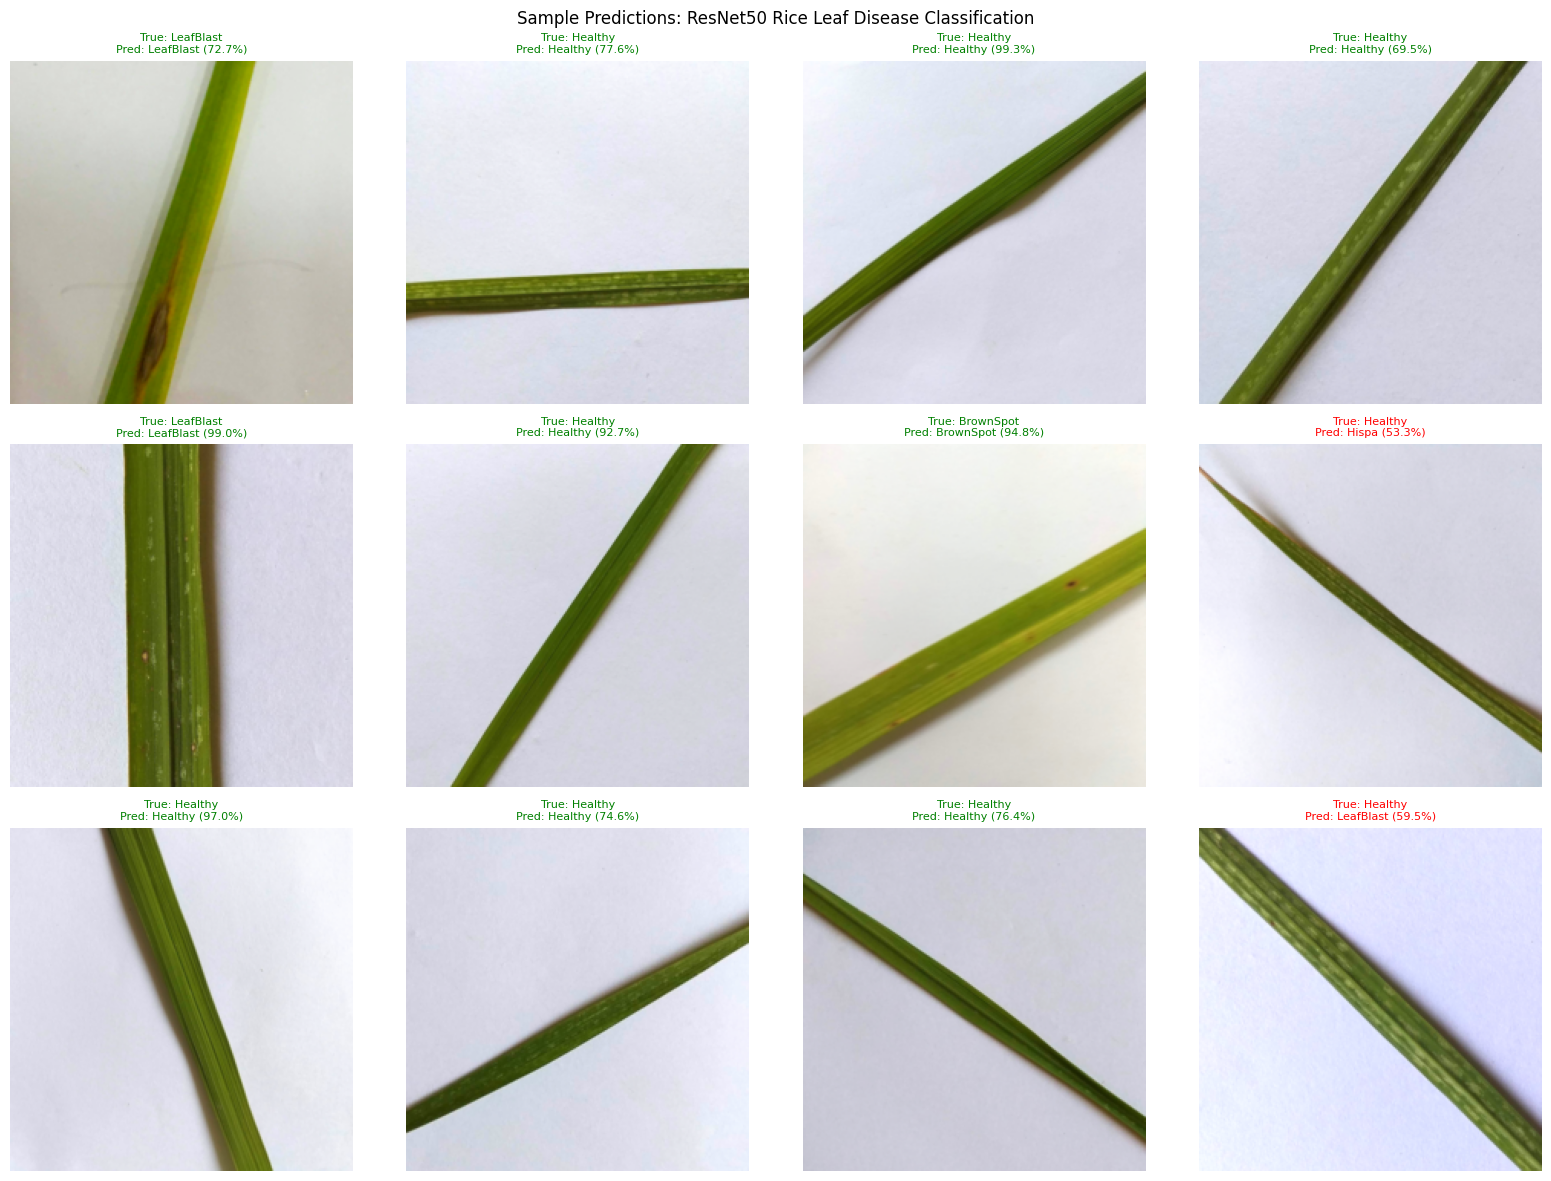

Sample predictions saved.


In [19]:
inv_mean = [-m / s for m, s in zip(mean, std)]
inv_std  = [1.0 / s for s in std]
denorm = transforms.Normalize(mean=inv_mean, std=inv_std)

model.eval()
sample_idx = random.sample(range(len(test_dataset)), 12)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Sample Predictions: ResNet50 Rice Leaf Disease Classification', fontsize=12)

for ax, idx in zip(axes.flatten(), sample_idx):
    img_tensor, true_label = test_dataset[idx]

    with torch.no_grad():
        output = model(img_tensor.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(output, dim=1)
        pred_label = output.argmax(dim=1).item()
        confidence = prob[0, pred_label].item() * 100

    img_show = denorm(img_tensor).permute(1, 2, 0).clamp(0, 1).numpy()

    true_name = class_names[true_label].replace('_', ' ')
    pred_name = class_names[pred_label].replace('_', ' ')
    color = 'green' if pred_label == true_label else 'red'

    ax.imshow(img_show)
    ax.set_title(
        f'True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)',
        color=color, fontsize=8
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample predictions saved.')

## Step 17: Final Summary (Copy These Numbers into Your Report)

In [20]:
total_params_final     = sum(p.numel() for p in model.parameters())
trainable_params_final = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params_final    = total_params_final - trainable_params_final

print('COPY THESE EXACT NUMBERS INTO YOUR REPORT')
print('=' * 60)
print('Dataset             : Rice Leaf Disease Dataset (Kaggle)')
print('Dataset source      : https://www.kaggle.com/datasets/minhhuy2810/rice-diseases-image-dataset')
print('Total images        :', total_size)
print('Train images        :', train_size)
print('Validation images   :', val_size)
print('Test images         :', test_size)
print('Number of classes   :', num_classes)
print('Class names         :', class_names)
print('Framework           : PyTorch', torch.__version__)
print('Model               : ResNet50 (IMAGENET1K_V2 pretrained)')
print('Input size          : 224 x 224 x 3')
print('Total parameters    :', f'{total_params_final:,}')
print('Trainable parameters:', f'{trainable_params_final:,}')
print('Frozen parameters   :', f'{frozen_params_final:,}')
print('Phase 1 epochs      :', EPOCHS_PHASE1)
print('Phase 2 epochs      :', EPOCHS_PHASE2)
print('Total epochs        :', EPOCHS_PHASE1 + EPOCHS_PHASE2)
print('Batch size          :', BATCH_SIZE)
print('Data split          : 75% train / 15% val / 10% test')
print('-' * 60)
print('Test Accuracy       :', round(test_acc  * 100, 2), '%')
print('Test Precision      :', round(test_prec * 100, 2), '%')
print('Test Recall         :', round(test_rec  * 100, 2), '%')
print('Test F1 Score       :', round(test_f1   * 100, 2), '%')
print('=' * 60)

COPY THESE EXACT NUMBERS INTO YOUR REPORT
Dataset             : Rice Leaf Disease Dataset (Kaggle)
Dataset source      : https://www.kaggle.com/datasets/minhhuy2810/rice-diseases-image-dataset
Total images        : 3355
Train images        : 2516
Validation images   : 503
Test images         : 336
Number of classes   : 4
Class names         : ['BrownSpot', 'Healthy', 'Hispa', 'LeafBlast']
Framework           : PyTorch 2.10.0+cu128
Model               : ResNet50 (IMAGENET1K_V2 pretrained)
Input size          : 224 x 224 x 3
Total parameters    : 24,033,604
Trainable parameters: 22,588,676
Frozen parameters   : 1,444,928
Phase 1 epochs      : 10
Phase 2 epochs      : 8
Total epochs        : 18
Batch size          : 32
Data split          : 75% train / 15% val / 10% test
------------------------------------------------------------
Test Accuracy       : 74.7 %
Test Precision      : 75.5 %
Test Recall         : 74.7 %
Test F1 Score       : 74.16 %
